--- 1. عرض أول صفين في الجدول ---
    Name  Age  Salary
0  Ahmed   25    5000
1   Mona   30    8000

--- 2. عرض عمود الأسماء فقط ---
0    Ahmed
1     Mona
2      Ali
3     Sara
Name: Name, dtype: object

--- 3. الأشخاص أكبر من 24 سنة ---
    Name  Age  Salary
0  Ahmed   25    5000
1   Mona   30    8000
3   Sara   28    7500

--- 4. الجدول بعد إضافة الراتب السنوي ---
    Name  Age  Salary  Yearly_Salary
0  Ahmed   25    5000          60000
1   Mona   30    8000          96000
2    Ali   22    4500          54000
3   Sara   28    7500          90000

--- 5. متوسط الأعمار ---
26.25


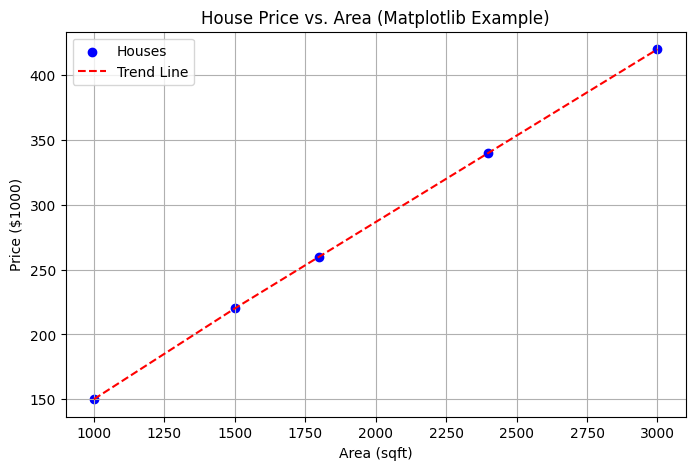

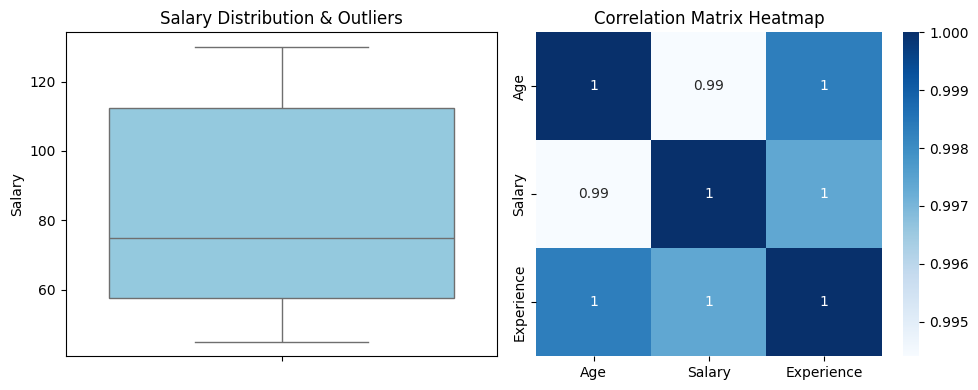

Scikit-Learn Model R2 Score: 99.74%
PyTorch Predicted output for x=5: 9.95


In [5]:
# ==========================================
# 1. Pandas
# ==========================================
import pandas as pd


data = {
    'Name': ['Ahmed', 'Mona', 'Ali', 'Sara'],
    'Age': [25, 30, 22, 28],
    'Salary': [5000, 8000, 4500, 7500]
}

df = pd.DataFrame(data)


print("--- 1. عرض أول صفين في الجدول ---")
print(df.head(2))

print("\n--- 2. عرض عمود الأسماء فقط ---")
print(df['Name'])

print("\n--- 3. الأشخاص أكبر من 24 سنة ---")
filtered_df = df[df['Age'] > 24]
print(filtered_df)

df['Yearly_Salary'] = df['Salary'] * 12
print("\n--- 4. الجدول بعد إضافة الراتب السنوي ---")
print(df)

print("\n--- 5. متوسط الأعمار ---")
print(df['Age'].mean())


# ==========================================
# 2. Matplotlib & NumPy
# ==========================================
import matplotlib.pyplot as plt
import numpy as np


area = np.array([1000, 1500, 1800, 2400, 3000])
price = np.array([150, 220, 260, 340, 420])

plt.figure(figsize=(8, 5))
plt.scatter(area, price, color='blue', marker='o', label='Houses')
plt.plot(area, price, color='red', linestyle='--', label='Trend Line') # خط الاتجاه

plt.title('House Price vs. Area (Matplotlib Example)')
plt.xlabel('Area (sqft)')
plt.ylabel('Price ($1000)')
plt.legend()
plt.grid(True)
plt.show()


# ==========================================
# 3. Seaborn
# ==========================================
import seaborn as sns


data_sns = {
    'Age': [25, 30, 35, 40, 22, 48, 55, 60],
    'Salary': [50, 60, 70, 80, 45, 110, 120, 130],
    'Experience': [2, 5, 8, 12, 1, 18, 22, 25]
}
df_sns = pd.DataFrame(data_sns)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_sns['Salary'], color='skyblue')
plt.title('Salary Distribution & Outliers')

plt.subplot(1, 2, 2)
sns.heatmap(df_sns.corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix Heatmap')

plt.tight_layout()
plt.show()


# ==========================================
# 4. Scikit-Learn (Sklearn)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)
X = np.random.rand(100, 2) * 100  # ميزتين (Features)
y = 3 * X[:, 0] + 2 * X[:, 1] + np.random.randn(100) * 5  # المتغير المستهدف (Target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"Scikit-Learn Model R2 Score: {r2_score(y_test, y_pred) * 100:.2f}%")


# ==========================================
# 5. PyTorch
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim

X_tensor = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)
y_tensor = torch.tensor([[2.0], [4.0], [6.0], [8.0]], dtype=torch.float32)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear(x)

torch_model = SimpleNN()

criterion = nn.MSELoss()
optimizer = optim.SGD(torch_model.parameters(), lr=0.01)

for epoch in range(100):
    y_pred_torch = torch_model(X_tensor)
    loss = criterion(y_pred_torch, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


test_val = torch.tensor([[5.0]], dtype=torch.float32)
predicted = torch_model(test_val)
print(f"PyTorch Predicted output for x=5: {predicted.item():.2f}")